In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [ ]:
DATA_DIR = "olist_data"

customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

In [ ]:
df = orders.merge(customers,on="customer_id")
df = df.merge(order_items,on="order_id")
df = df.merge(payments,on="order_id")
df = df.merge(products,on="product_id")

print(df.shape)

(117601, 30)


In [ ]:
# First 5 Rows
print(df.head())


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10

In [ ]:
# Last 5 Rows
print(df.tail(5))

                                order_id                       customer_id  \
117596  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
117597  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
117598  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
117599  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
117600  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

       order_status order_purchase_timestamp    order_approved_at  \
117596    delivered      2018-02-06 12:58:58  2018-02-06 13:10:37   
117597    delivered      2017-08-27 14:46:43  2017-08-27 15:04:16   
117598    delivered      2018-01-08 21:28:27  2018-01-08 21:36:21   
117599    delivered      2018-01-08 21:28:27  2018-01-08 21:36:21   
117600    delivered      2018-03-08 20:57:30  2018-03-09 11:20:28   

       order_delivered_carrier_date order_delivered_customer_date  \
117596          2018-02-07 23:22:42           2

In [ ]:
# Shape
print(df.shape)

(117601, 30)


In [ ]:
# Columns
print(df.columns)


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')


In [ ]:
# Datatypes
print(df.dtypes)


order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_item_id                      int64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
payment_sequential                 int64
payment_type                      object
payment_installments               int64
payment_value                    float64
product_category_name             object
product_name_lenght              float64
product_descript

In [ ]:
# Missing Values
print(df.isnull().sum())

# Remove Duplicates
df = df.drop_duplicates()

# Fill Missing Values
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill  Missing Values
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
product_category_name            1698
product_name_lenght              1698
product_description_lenght       1698
product_photos_qty               1698
product_weig

In [ ]:
# Dataset Information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117601 non-null  object 
 1   customer_id                    117601 non-null  object 
 2   order_status                   117601 non-null  object 
 3   order_purchase_timestamp       117601 non-null  object 
 4   order_approved_at              117601 non-null  object 
 5   order_delivered_carrier_date   117601 non-null  object 
 6   order_delivered_customer_date  117601 non-null  object 
 7   order_estimated_delivery_date  117601 non-null  object 
 8   customer_unique_id             117601 non-null  object 
 9   customer_zip_code_prefix       117601 non-null  int64  
 10  customer_city                  117601 non-null  object 
 11  customer_state                 117601 non-null  object 
 12  order_item_id                 

In [ ]:
# Statistical Summary
print(df.describe())

       customer_zip_code_prefix  order_item_id          price  freight_value  \
count             117601.000000  117601.000000  117601.000000  117601.000000   
mean               35051.793097       1.195900     120.824783      20.045990   
std                29820.588877       0.697706     184.479323      15.861315   
min                 1003.000000       1.000000       0.850000       0.000000   
25%                11310.000000       1.000000      39.900000      13.080000   
50%                24315.000000       1.000000      74.900000      16.290000   
75%                58600.000000       1.000000     134.900000      21.190000   
max                99990.000000      21.000000    6735.000000     409.680000   

       payment_sequential  payment_installments  payment_value  \
count       117601.000000         117601.000000  117601.000000   
mean             1.093528              2.939482     172.686752   
std              0.726692              2.774223     267.592290   
min            

In [ ]:
# loc
print(df.loc[0:5])



                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
5  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
5    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   

  order_delivered_carrier_date order_de

In [ ]:
# Specific Columns
print(df.loc[0:5,["price","payment_value"]])



    price  payment_value
0   29.99          18.12
1   29.99           2.00
2   29.99          18.59
3  118.70         141.46
4  159.90         179.12
5   45.00          72.20


In [ ]:
# iloc
print(df.iloc[0:5])



                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10

In [ ]:
# Row and Column Position
print(df.iloc[0:5,0:5])

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15  
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15  
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15  
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27  
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23  


In [ ]:
# High Price Products
high_price = df[df["price"] > 500]

print(high_price.shape)



(3382, 30)


In [ ]:
# Delivered Orders
delivered = df[df["order_status"]=="delivered"]

print(delivered.shape)


(115035, 30)


In [ ]:
# Ascending
print(df.sort_values("price").head())

# Descending
print(df.sort_values("price",ascending=False).head())

                                order_id                       customer_id  \
83908   3ee6513ae7ea23bdfab5b9ab60bffcb5  161b6d415e8b3413c6609c70cf405b5a   
98340   6e864b3f0ec71031117ad4cf46b7f2a1  9f9d249355f63c5c1216a82b802452c1   
62184   c5bdd8ef3c0ec420232e668302179113  5af78bf1a82a2660d1e3fd78c645f58f   
104921  8272b63d03f5f79c56e9e4120aec44ef  fc3d1daec319d62d49bfb5e1f83123e9   
104922  8272b63d03f5f79c56e9e4120aec44ef  fc3d1daec319d62d49bfb5e1f83123e9   

       order_status order_purchase_timestamp    order_approved_at  \
83908     delivered      2018-04-24 11:01:06  2018-04-26 03:55:26   
98340     delivered      2018-04-24 20:15:21  2018-04-24 20:33:18   
62184     delivered      2018-04-27 12:37:10  2018-04-28 02:55:22   
104921    delivered      2017-07-16 18:19:25  2017-07-17 18:25:23   
104922    delivered      2017-07-16 18:19:25  2017-07-17 18:25:23   

       order_delivered_carrier_date order_delivered_customer_date  \
83908           2018-04-26 13:28:00           2

In [ ]:
# Query Method
query_data = df.query("price > 100")

print(query_data.shape)

(41925, 30)


In [ ]:
state_revenue = df.groupby("customer_state")["payment_value"].sum()

print(state_revenue.head())


customer_state
AC     24984.86
AL    111284.42
AM     34753.30
AP     21642.70
BA    797410.36
Name: payment_value, dtype: float64


In [ ]:
category_sales = df.groupby("product_category_name")["price"].sum()

print(category_sales.head())

product_category_name
Unknown                      190956.59
agro_industria_e_comercio     83841.95
alimentos                     30119.44
alimentos_bebidas             16363.53
artes                         24721.97
Name: price, dtype: float64


In [ ]:
summary = df.groupby("customer_state").agg(
    Total_Revenue=("payment_value","sum"),
    Average_Price=("price","mean"),
    Order_Count=("order_id","count")
)

print(summary.head())

                Total_Revenue  Average_Price  Order_Count
customer_state                                           
AC                   24984.86     179.573053           95
AL                  111284.42     181.463668          458
AM                   34753.30     133.388070          171
AP                   21642.70     162.551190           84
BA                  797410.36     133.747826         4048


In [ ]:
df["order_status"] = df["order_status"].replace(
    {
        "delivered":"Delivered",
        "shipped":"Shipped"
    }
)

df.rename(
    columns={"price":"Product_Price"},
    inplace=True
)

print(df.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    Delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    Delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    Delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    Delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    Delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.corr())

                            customer_zip_code_prefix  order_item_id  \
customer_zip_code_prefix                    1.000000       0.000157   
order_item_id                               0.000157       1.000000   
Product_Price                               0.043318      -0.060488   
freight_value                               0.225454      -0.030568   
payment_sequential                         -0.021183      -0.002393   
payment_installments                        0.056926       0.073499   
payment_value                               0.054976       0.264328   
product_name_lenght                         0.015277      -0.023107   
product_description_lenght                  0.025134      -0.014494   
product_photos_qty                          0.020163      -0.053295   
product_weight_g                            0.001588      -0.004613   
product_length_cm                           0.004142       0.004704   
product_height_cm                           0.011508       0.028835   
produc

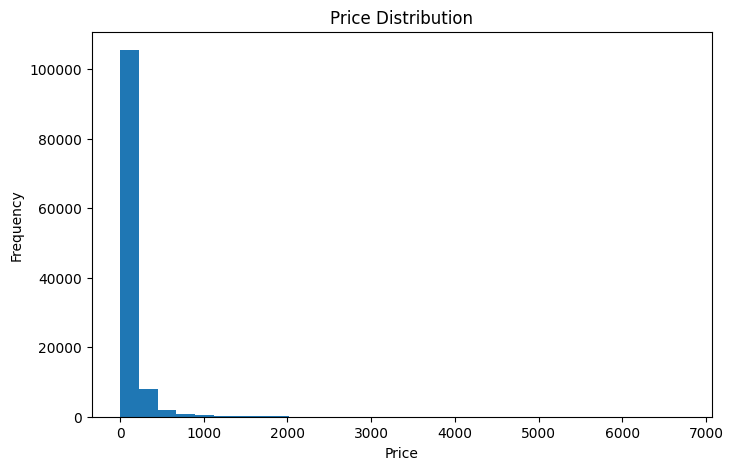

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Product_Price"],bins=30)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

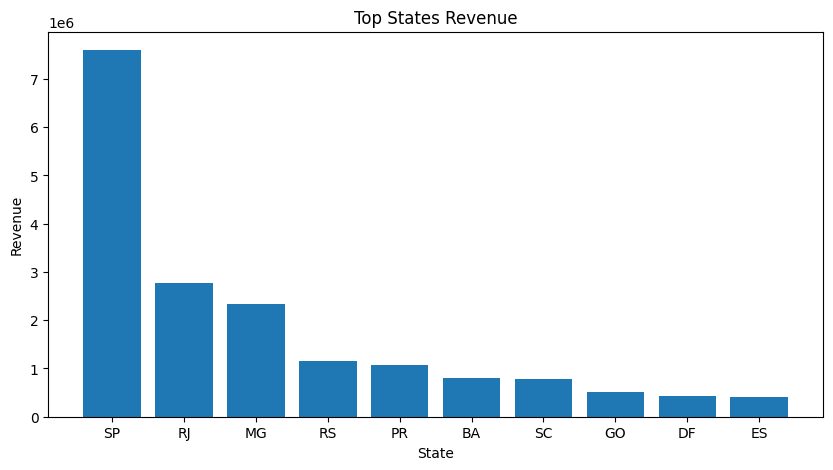

In [ ]:
top_states = df.groupby("customer_state")["payment_value"] \
               .sum() \
               .sort_values(ascending=False) \
               .head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_states.index,
    top_states.values
)

plt.title("Top States Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

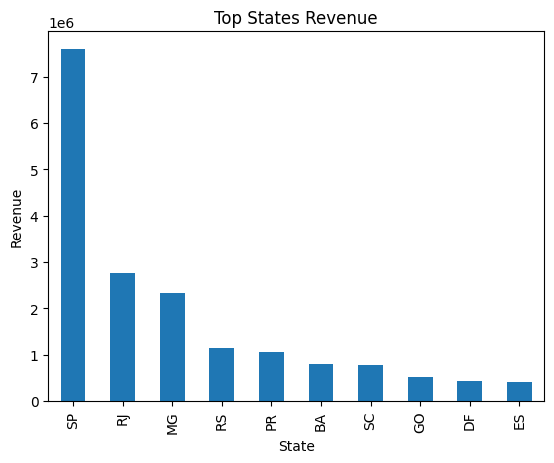

In [ ]:
top_states = df.groupby("customer_state")["payment_value"] \
               .sum() \
               .sort_values(ascending=False) \
               .head(10).plot(kind="bar")

# plt.bar(
#     top_states.index,
#     top_states.values
# )

plt.title("Top States Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

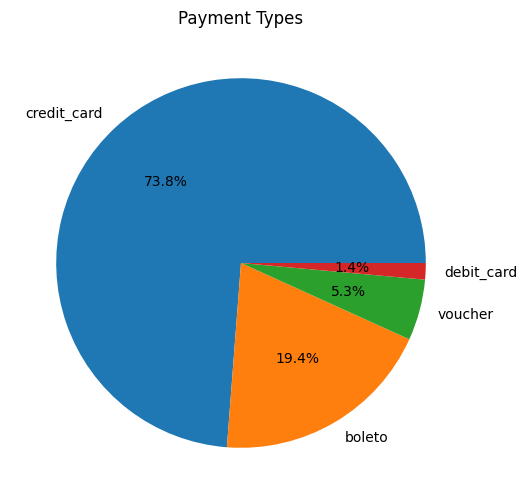

In [ ]:
payment_counts = df["payment_type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Payment Types")

plt.show()

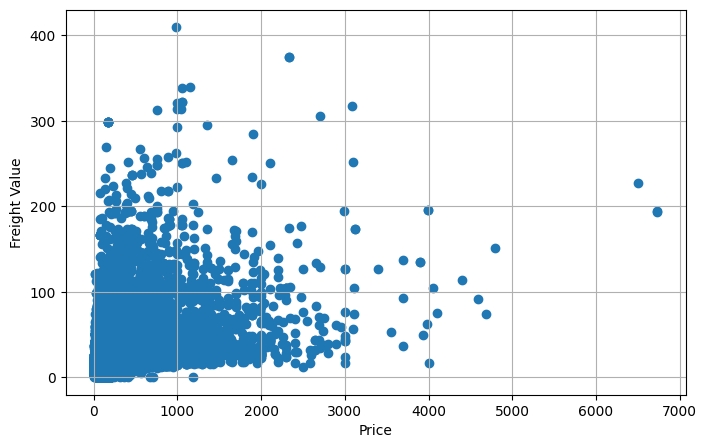

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Product_Price"],
    df["freight_value"]
)

plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.grid(True)
plt.show()

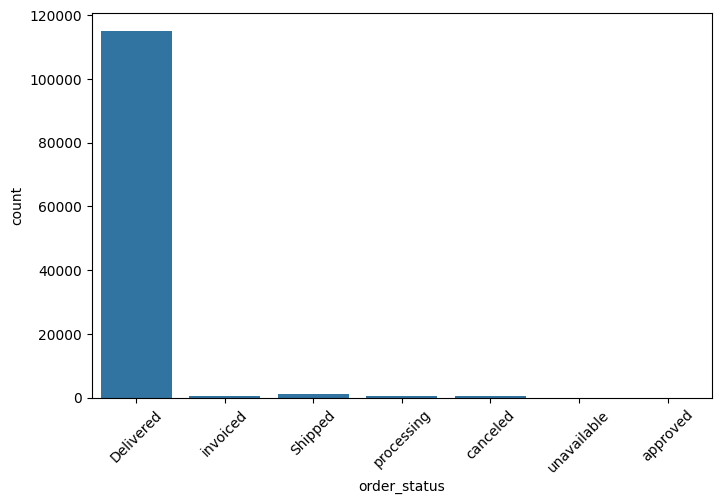

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="order_status"
)

plt.xticks(rotation=45)

plt.show()

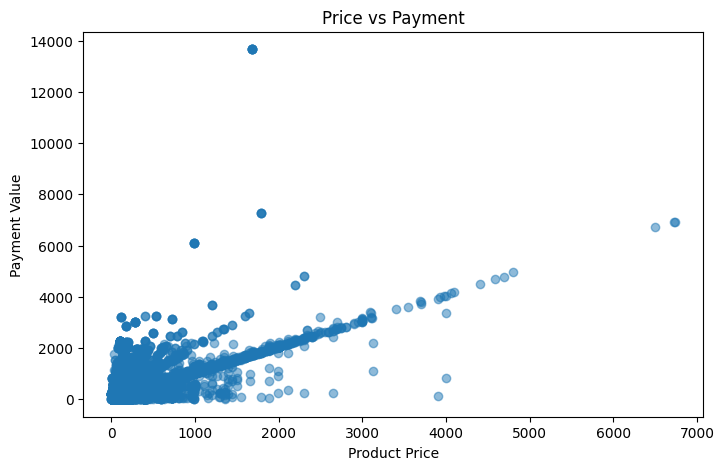

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Product_Price"],
    df["payment_value"],
    alpha=0.5
)

plt.xlabel("Product Price")
plt.ylabel("Payment Value")
plt.title("Price vs Payment")

plt.show()

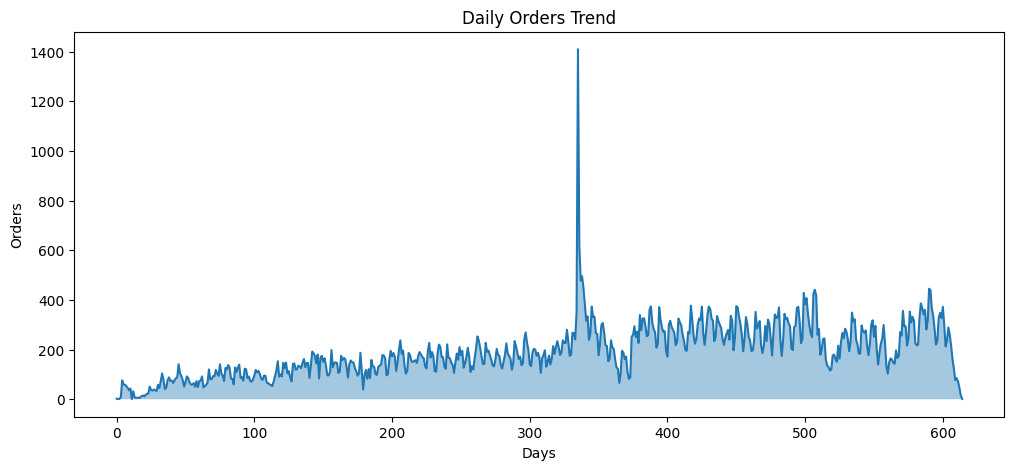

In [ ]:
daily_orders = (
    df.groupby(
        pd.to_datetime(
            df["order_purchase_timestamp"]
        ).dt.date
    )["order_id"]
    .count()
)

x = range(len(daily_orders))
y = daily_orders.values

plt.figure(figsize=(12,5))

plt.plot(x, y)

plt.fill_between(
    x,
    y,
    alpha=0.4
)

plt.title("Daily Orders Trend")
plt.xlabel("Days")
plt.ylabel("Orders")

plt.show()

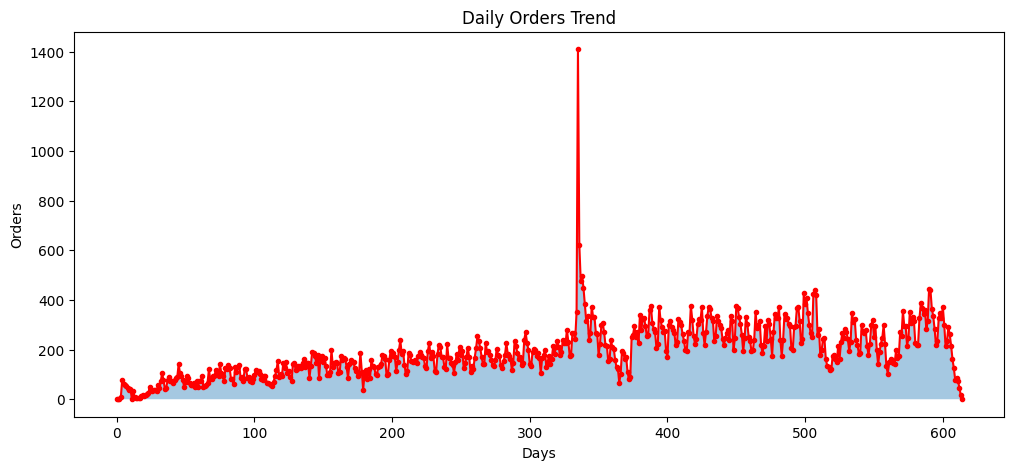

In [ ]:
daily_orders = (
    df.groupby(
        pd.to_datetime(
            df["order_purchase_timestamp"]
        ).dt.date
    )["order_id"]
    .count()
)

x = range(len(daily_orders))
y = daily_orders.values

plt.figure(figsize=(12,5))

plt.plot(x, y,color = "red", linestyle="-",marker=".")

plt.fill_between(
    x,
    y,
    alpha=0.4
)

plt.title("Daily Orders Trend")
plt.xlabel("Days")
plt.ylabel("Orders")

plt.show()

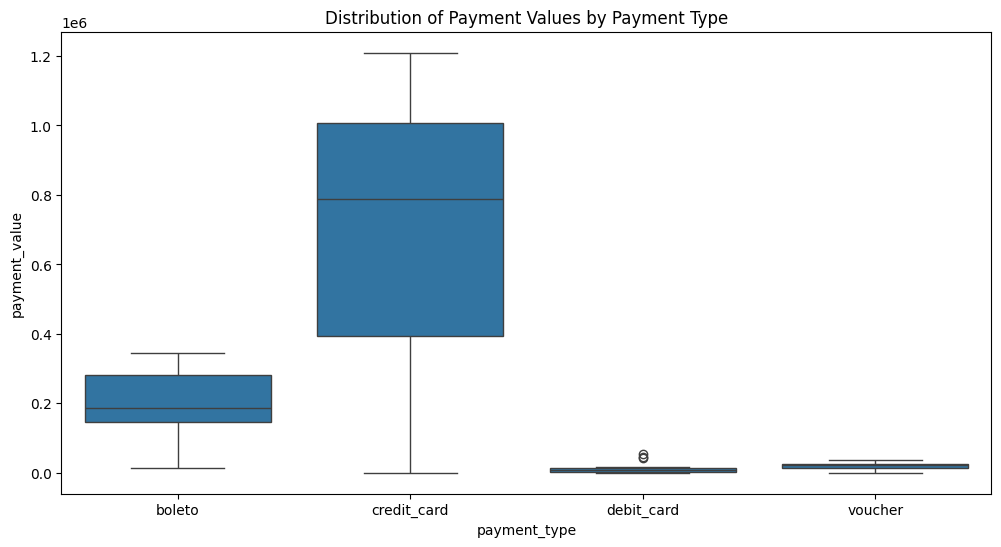

In [ ]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

grouped_df = df.groupby(["payment_type", "purchase_month"])[["payment_value"]].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=grouped_df,
    x="payment_type",
    y="payment_value"
)

plt.title("Distribution of Payment Values by Payment Type")
plt.show()


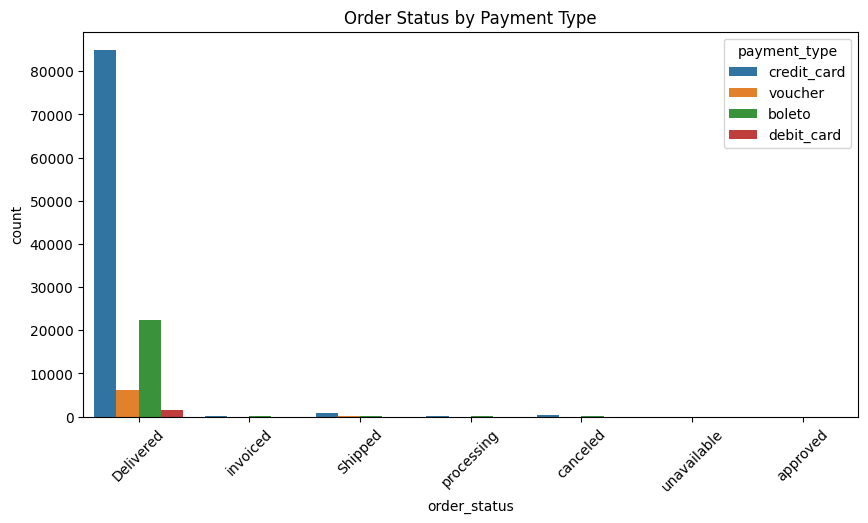

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="order_status",
    hue="payment_type"
)

plt.xticks(rotation=45)

plt.title("Order Status by Payment Type")

plt.show()

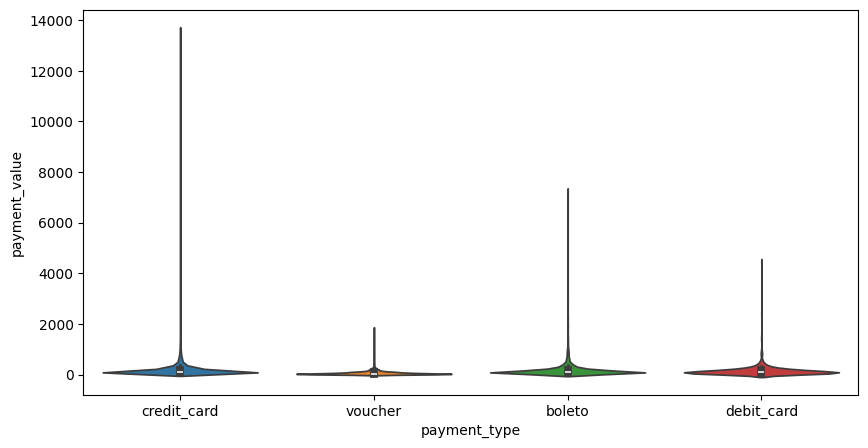

In [ ]:
plt.figure(figsize=(10,5))

sns.violinplot(
    data=df,
    x="payment_type",
    y="payment_value",
    hue="payment_type"
)

plt.show()

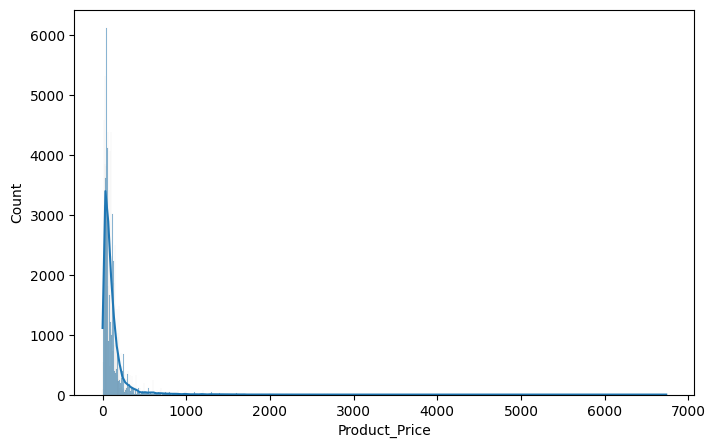

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Product_Price",
    kde=True
)

plt.show()

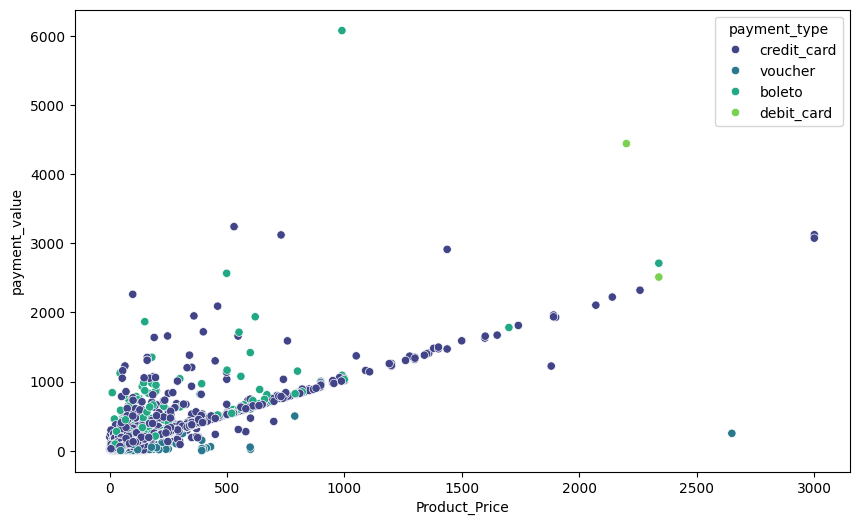

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x="Product_Price",
    y="payment_value",
    hue="payment_type",
    palette="viridis"
)

plt.show()

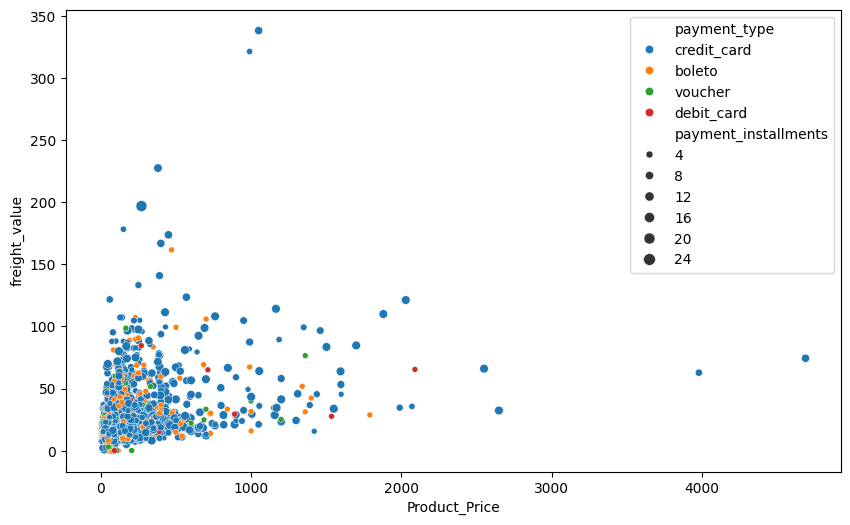

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x="Product_Price",
    y="freight_value",
    hue="payment_type",
    size="payment_installments"
)

plt.show()

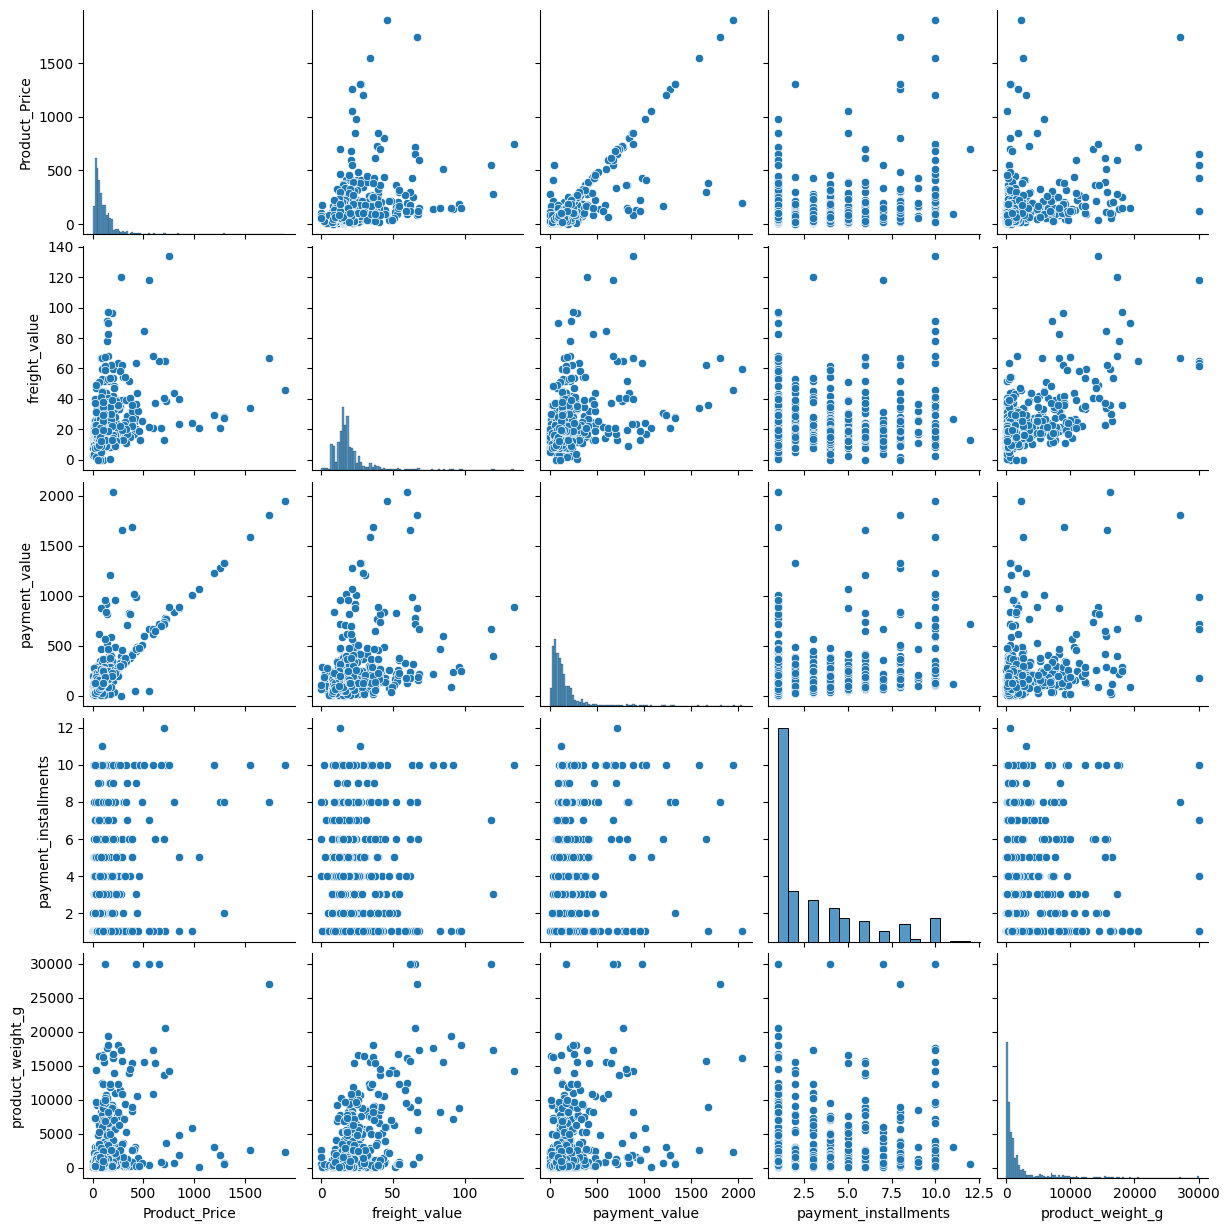

In [ ]:
cols = [
    "Product_Price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "product_weight_g"
]

sns.pairplot(df[cols].sample(1000))

plt.show()

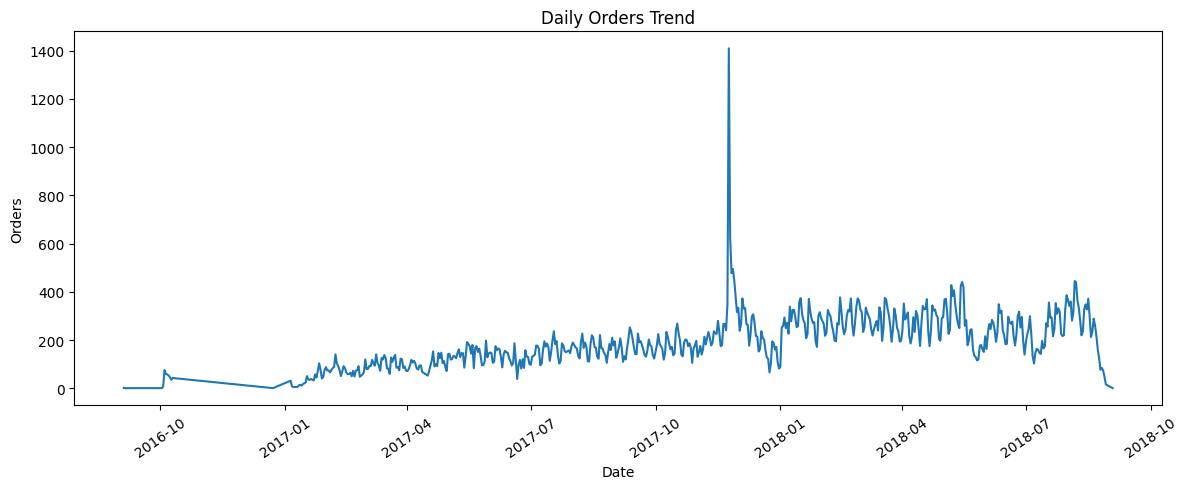

In [ ]:
daily_orders = (
    df.groupby(
        pd.to_datetime(
            df["order_purchase_timestamp"]
        ).dt.date
    )["order_id"]
    .count()
)

plt.figure(figsize=(12,5))

plt.plot(
    daily_orders.index,
    daily_orders.values
)

plt.title("Daily Orders Trend")
plt.xlabel("Date")
plt.ylabel("Orders")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

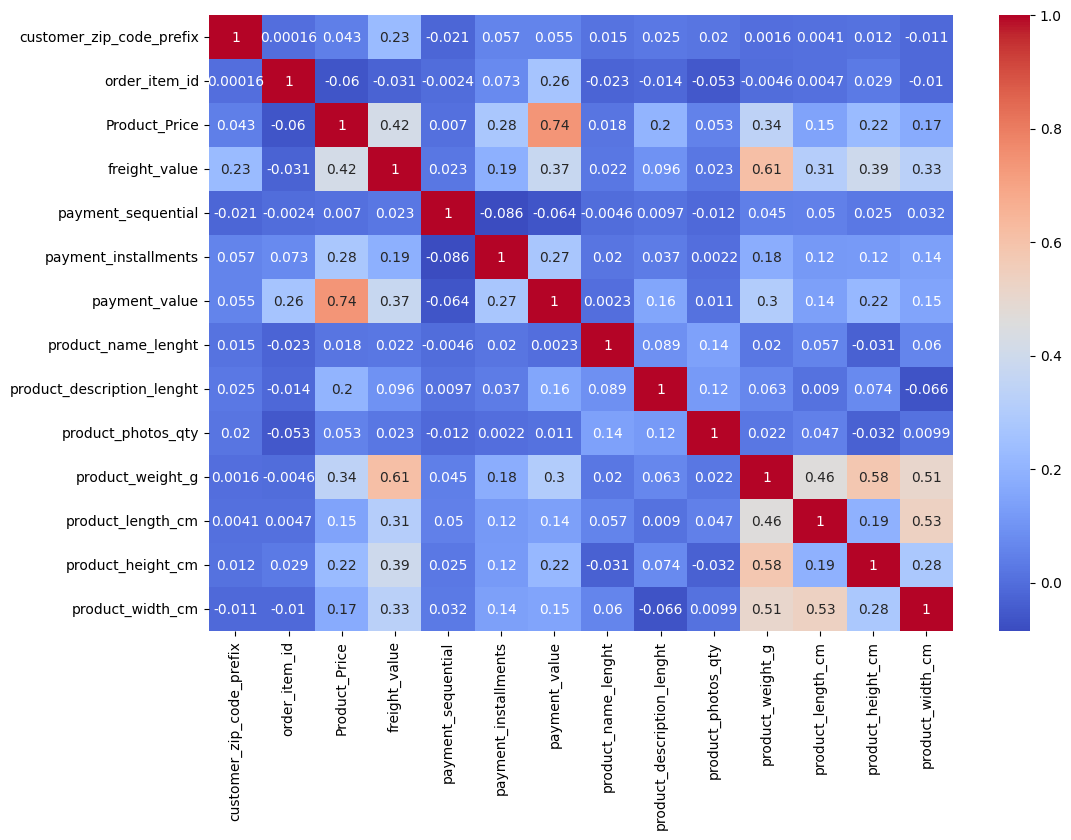

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

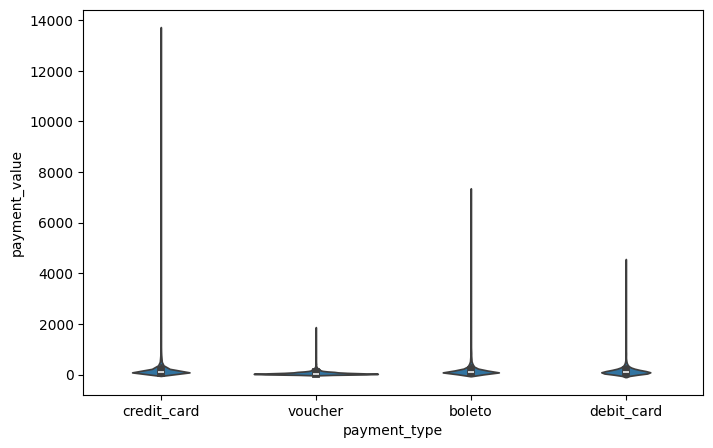

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="payment_type",
    y="payment_value"
)

plt.show()

In [ ]:
df.to_csv(
    "olist_cleaned_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'Product_Price', 'freight_value',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'purchase_month'],
      dtype='object')